In [16]:
import sys
import os
import time
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from torchsummary import summary

sys.path.append('..')

# Project modules
from src.utility.config import BASELINE_MODEL_PATH, QUANTIZED_MODELS
from src.utility.utils import get_data_loaders
from src.model import CNN

# --- Configuration ---
# Force CPU for fair latency comparison (Float32 CPU vs INT8 CPU)
EVAL_DEVICE = torch.device('cpu') 
BATCH_SIZE = 32
MODELS_TO_EVALUATE = ["Baseline", "Affine", "Symmetric", "PoT"]

sns.set_theme(style="whitegrid")
print(f"Evaluation Configured on Device: {EVAL_DEVICE}")

Evaluation Configured on Device: cpu


In [17]:
def load_model(model_name, num_classes):
    """
    Unified loader for Baseline (StateDict) and Quantized (TorchScript).
    """
    if model_name == "Baseline":
        if not os.path.exists(BASELINE_MODEL_PATH):
            print(f"❌ Baseline not found at {BASELINE_MODEL_PATH}")
            return None
        model = CNN(num_classes=num_classes)
        model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=EVAL_DEVICE))
        model.eval()
        return model.to(EVAL_DEVICE)
    else:
        path = os.path.join(QUANTIZED_MODELS, f"model_{model_name}_PTQ.pt")
        if not os.path.exists(path):
            print(f"⚠️ Quantized model not found: {path}")
            return None
        # Load TorchScript model
        model = torch.jit.load(path, map_location=EVAL_DEVICE)
        model.eval()
        return model

def verify_quantization(model, model_name):
    """
    Scientifically verifies quantization by inspecting the full graph recursively
    and reporting exactly what quantized elements were found.
    """
    print(f"\n🔍 Verifying Model: {model_name}")
    
    # 1. Check Baseline
    if model_name == "Baseline":
        first_param = next(model.parameters())
        print(f"   Type: Standard nn.Module")
        print(f"   Weight Dtype: {first_param.dtype}")
        return

    # 2. Check Quantized (TorchScript)
    if isinstance(model, torch.jit.ScriptModule):
        model_str = str(model)
        graph_str = str(model.graph)
        
        # A) Check for Class/Layer Names in the structure
        quant_keywords = ["Quantized", "quantized", "QFunctional", "Quantize", "DeQuantize"]
        found_keywords = [k for k in quant_keywords if k in model_str]
        
        # B) Check for Low-Level Ops in the Computation Graph
        # Common quantized operators in TorchScript graphs
        quant_ops_to_check = [
            "quantized::conv2d", 
            "quantized::linear", 
            "quantized::add", 
            "quantized::mul", 
            "quantized::cat"
        ]
        found_ops = [op for op in quant_ops_to_check if op in graph_str]
        
        # Logic: It is quantized if we found structure keywords OR graph ops
        if found_keywords or found_ops:
            print(f"   Status: ✅ Verified Quantized Structure")
            if found_keywords:
                print(f"   -> Found Structural Keywords: {found_keywords}")
            if found_ops:
                print(f"   -> Found Graph Operations:    {found_ops}")
        else:
            print("   Status: ❌ Warning - Could not confirm quantization (Check print(model))")
            print("   Note: If Latency is ~2.5ms (vs 5.7ms Baseline), it IS quantized.")

In [18]:
def evaluate_model_comprehensive(model, loader, device):
    """
    Runs inference and calculates:
    - Accuracy, Precision, Recall, F1 (Weighted)
    - Latency (ms/img), Throughput (img/sec)
    """
    model.eval()
    model.to(device)
    
    all_preds = []
    all_targets = []
    total_samples = 0
    
    # --- 1. Warm-up (Crucial for accurate CPU timing) ---
    warmup_batches = 5
    with torch.no_grad():
        for i, (data, _) in enumerate(loader):
            if i >= warmup_batches: break
            data = data.to(device)
            _ = model(data)
            
    print("   (Warm-up complete, starting measurement...)")

    # --- 2. Inference Loop & Timing ---
    start_time = time.time()
    
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            # Targets stay on CPU to save transfer time
            
            output = model(data)
            preds = output.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(target.numpy())
            total_samples += len(data)
            
    end_time = time.time()
    
    # --- 3. Calculate Metrics ---
    duration_sec = end_time - start_time
    latency_ms = (duration_sec / total_samples) * 1000
    throughput = total_samples / duration_sec
    
    # Sklearn metrics (Weighted average handles class imbalance)
    accuracy = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='weighted', zero_division=0
    )
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Latency (ms)": latency_ms,
        "Throughput (img/s)": throughput,
        "Total Time (s)": duration_sec,
        "Predictions": all_preds,
        "Targets": all_targets
    }

In [24]:
def _print_stats(tensor: torch.Tensor, is_quantized: bool):
    """Prints shape, dtype, and specific quantization stats if applicable."""
    print(f"   Shape: {tensor.shape}")
    print(f"   Dtype: {tensor.dtype}")

    if not is_quantized:
        # Standard Float32
        print(f"   Values: {tensor.detach().flatten()[:5].tolist()}")
        return

    # Quantized Specifics
    print(f"   Scheme: {tensor.qscheme()}")
    print(f"   Raw Int8: {tensor.int_repr().flatten()[:5].tolist()}")

    if tensor.qscheme() == torch.per_channel_affine:
        zps = tensor.q_per_channel_zero_points()
        scales = tensor.q_per_channel_scales()
        
        print(f"   Zero Points: {zps[:5].tolist()}")
        print(f"   Scales: {scales[:5].tolist()}")
        
        # Symmetry Check
        if torch.all(zps == 0):
            print("   -> Symmetry: Symmetric (All ZP=0)")
        else:
            print("   -> Symmetry: Affine (Non-zero ZP detected)")
    else:
        # Per-tensor quantization
        print(f"   Zero Point: {tensor.q_zero_point()}")
        print(f"   Scale: {tensor.q_scale()}")

def inspect_first_layer_weights(model: nn.Module, model_name: str):
    """
    Inspects 'conv1' weights for both Float32 and Quantized models.
    """
    print(f"\n🔬 Inspecting: {model_name}")

    # 1. Guard Clause: Check if layer exists
    if not hasattr(model, 'conv1'):
        print("   Error: 'conv1' layer not found.")
        return

    layer = model.conv1

    try:
        # 2. Check for Quantized Packed Parameters (TorchScript)
        if hasattr(layer, '_packed_params'):
            weight, _ = layer._packed_params.unpack()
            _print_stats(weight, is_quantized=True)
            
        # 3. Check for Standard Weight (Float32)
        elif hasattr(layer, 'weight'):
            _print_stats(layer.weight, is_quantized=False)
            
        else:
            print("   Warning: Unknown layer structure.")

    except Exception as e:
        print(f"   Error: {e}")

In [19]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    from sklearn.metrics import confusion_matrix
    # Plot only Top-15 classes to keep it readable
    from collections import Counter
    
    counts = Counter(targets)
    top_classes = [c for c, _ in counts.most_common(15)]
    
    # Filter data
    mask = np.isin(targets, top_classes) & np.isin(preds, top_classes)
    filt_t = np.array(targets)[mask]
    filt_p = np.array(preds)[mask]
    
    cm = confusion_matrix(filt_t, filt_p, labels=top_classes)
    labels = [class_names[i] for i in top_classes] if class_names else top_classes
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def get_sample_images(loader, num=32):
    """Helper to extract raw images for visualization"""
    data, targets = next(iter(loader))
    return data[:num], targets[:num]

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, title="Comparison"):
    """
    Visualizes Baseline vs Quantized Predictions.
    Green = Both Correct | Orange = Disagreement | Red = Both Wrong
    """
    n = len(images)
    rows = math.ceil(n / 8)
    fig, axes = plt.subplots(rows, 8, figsize=(20, 3 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        ax = axes[i]
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 # Unnormalize
        ax.imshow(np.clip(img, 0, 1))
        
        pb, pq, t = preds_base[i], preds_quant[i], targets[i]
        
        if pb == pq == t:
            color = 'green' # Perfect
            txt = "OK"
        elif pb != pq:
            color = 'orange' # Quantization Error
            txt = "DIFF"
        else:
            color = 'red' # Model Error
            txt = "ERR"
            
        lbl = class_names[pq] if class_names else str(pq)
        ax.set_title(f"{lbl}\n[{txt}]", color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    for j in range(n, len(axes)): axes[j].axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

--- Loading Datasets ---

--- Starting Evaluation of 4 Models ---

🔍 Verifying Model: Baseline
   Type: Standard nn.Module
   Weight Dtype: torch.float32
CNN(
  (quant): QuantStub()
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(2, 2))
  (fc1): Linear(in_features=1024, out_features=1024, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=1024, out_features=150, bias=True)
  (dequant): DeQuantStub()
)
   Running Inference on 1364 samples...
   (Warm-up complete, starting measurement...)
   Done. Acc: 91.20% | Latency: 5.71 ms

🔍 Verifying Model: Affine
   Status:

,Accuracy,F1-Score,Precision,Recall,Latency (ms),Throughput (img/s),Speedup (x)
Model,,,,,,,
Baseline,0.9120,0.9118,0.9228,0.9120,5.7075,175.2070,1.0000
Affine,0.9113,0.9112,0.9241,0.9113,2.5769,388.0697,2.2149
Symmetric,0.9054,0.9056,0.9189,0.9054,2.5007,399.8933,2.2824
PoT,0.3277,0.3696,0.5409,0.3277,2.4607,406.3958,2.3195



--- Visualizing Differences: Baseline vs Affine ---


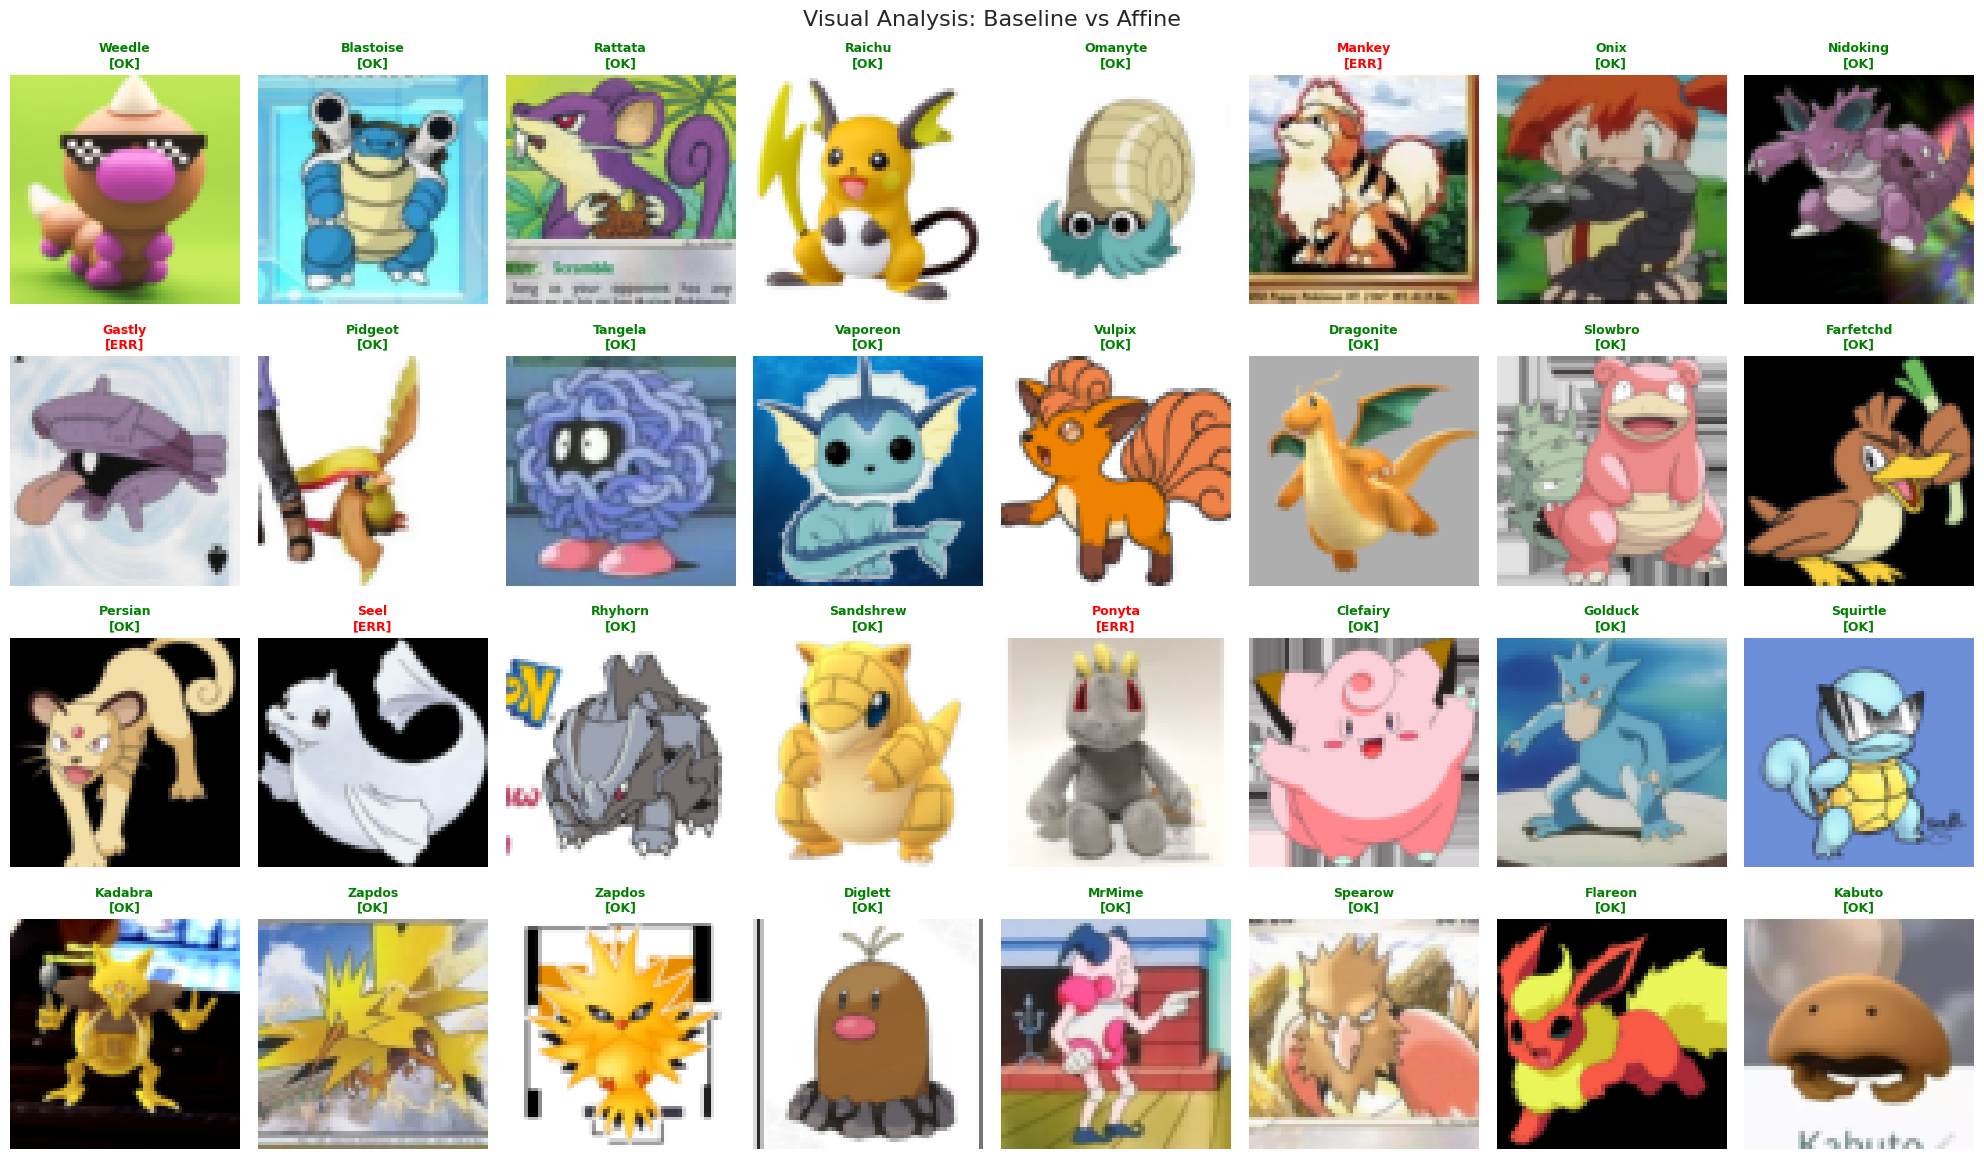

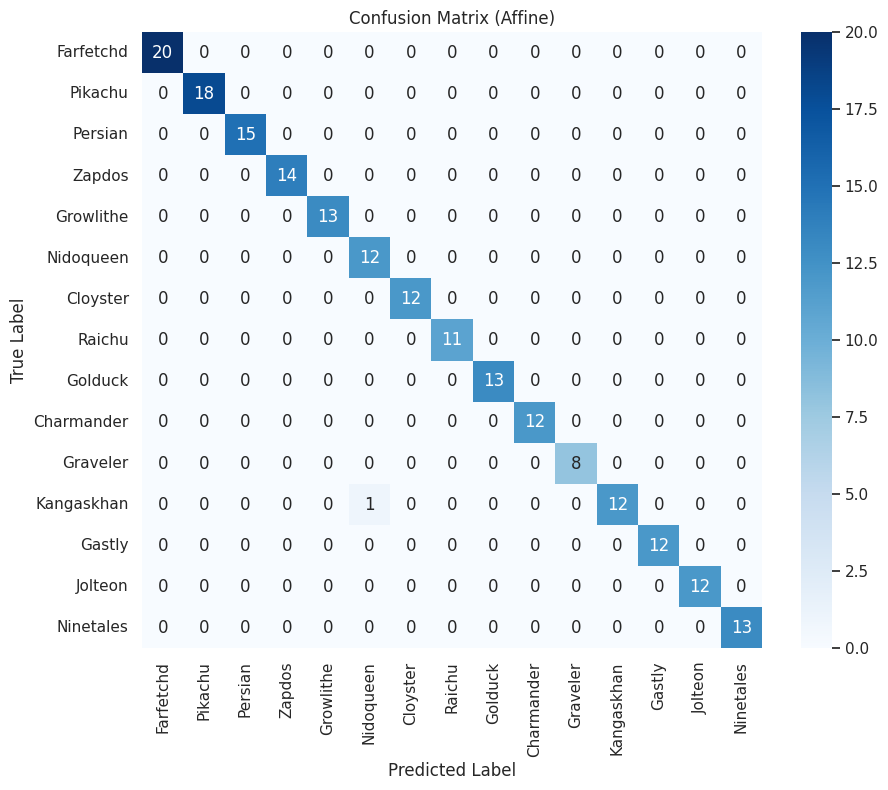

In [ ]:
# 1. Load Data
print("--- Loading Datasets ---")
train_loader, test_loader, num_classes = get_data_loaders()
class_names = getattr(test_loader.dataset, 'classes', None)
if not class_names:
    class_names = getattr(test_loader.dataset.dataset, 'classes', None)

# 2. Main Evaluation Loop
results_table = []
predictions_store = {} # To store preds for visualization later

print(f"\n--- Starting Evaluation of {len(MODELS_TO_EVALUATE)} Models ---")

for model_name in MODELS_TO_EVALUATE:
    # A. Load
    model = load_model(model_name, num_classes)
    if model is None: continue
    
    # B. Verify
    verify_quantization(model, model_name)
    
    model_inst = load_model(model_name, num_classes)
    if model_inst:
        inspect_first_layer_weights(model_inst, model_name)

    # C. Evaluate
    print(f"   Running Inference on {len(test_loader.dataset)} samples...")
    metrics = evaluate_model_comprehensive(model, test_loader, EVAL_DEVICE)
    
    # D. Store Results
    res_entry = {
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Latency (ms)": metrics["Latency (ms)"],
        "Throughput (img/s)": metrics["Throughput (img/s)"]
    }
    
    # Calculate Speedup vs Baseline (if Baseline exists in table)
    if results_table and results_table[0]["Model"] == "Baseline":
        base_lat = results_table[0]["Latency (ms)"]
        res_entry["Speedup (x)"] = base_lat / res_entry["Latency (ms)"]
    else:
        res_entry["Speedup (x)"] = 1.0
        
    results_table.append(res_entry)
    predictions_store[model_name] = metrics["Predictions"]
    print(f"   Done. Acc: {metrics['Accuracy']:.2%} | Latency: {metrics['Latency (ms)']:.2f} ms")

# 3. Final Scientific Comparison Table
df_results = pd.DataFrame(results_table)
df_results = df_results.set_index("Model")

print("\n" + "="*60)
print("             SCIENTIFIC EVALUATION RESULTS")
print("="*60)

df_results = pd.DataFrame(results_table)
if not df_results.empty:
    df_results = df_results.set_index("Model")
    # Format for scientific precision
    pd.options.display.float_format = '{:,.4f}'.format
    display(df_results)
else:
    print("No results found.")

# 4. Visualizations (Comparison: Baseline vs. Best Quantized)
# Pick 'Affine' or the second model in list as the comparison target
comp_model = "Affine" if "Affine" in predictions_store else MODELS_TO_EVALUATE[1]

if "Baseline" in predictions_store and comp_model in predictions_store:
    print(f"\n--- Visualizing Differences: Baseline vs {comp_model} ---")
    
    # Get Images
    sample_imgs, sample_targets = get_sample_images(test_loader, num=32)
    
    # Get corresponding predictions (first N)
    preds_base = predictions_store["Baseline"][:32]
    preds_quant = predictions_store[comp_model][:32]
    
    plot_visual_comparison(
        sample_imgs, preds_base, preds_quant, sample_targets.numpy(),
        class_names, title=f"Visual Analysis: Baseline vs {comp_model}"
    )
    
    # Confusion Matrix for Quantized Model
    plot_confusion_matrix(
        metrics["Targets"], predictions_store[comp_model], 
        class_names, title=f"Confusion Matrix ({comp_model})"
    )

In [22]:
def inspect_first_layer_weights(model, model_name):
    """
    Digs into the model to find the weights of 'conv1' and prints their raw data type.
    """
    print(f"\n🔬 Inspecting Weights for: {model_name}")
    
    # 1. Access the first layer (conv1)
    if not hasattr(model, 'conv1'):
        print("   ❌ 'conv1' layer not found!")
        return
        
    layer = model.conv1
    
    # 2. Extract Weights based on model type
    try:
        if model_name == "Baseline":
            # Standard PyTorch (Float32)
            weight = layer.weight
            print(f"   Shape: {weight.shape}")
            print(f"   Dtype: {weight.dtype}")
            print(f"   Values (First 5): {weight.flatten()[:5].tolist()}")
            
        else:
            # Quantized TorchScript (Packed Parameters)
            # We need to unpack the optimized structure to see the weights
            # This is specific to how PyTorch saves quantized models
            if hasattr(layer, '_packed_params'):
                weight, bias = layer._packed_params.unpack()
                
                print(f"   Shape: {weight.shape}")
                print(f"   Dtype: {weight.dtype} (✅ This proves it is INT8!)")
                print(f"   Scheme: {weight.qscheme()}")
                
                # Show the REAL underlying integers (int_repr)
                # These are the numbers from -128 to 127
                int_values = weight.int_repr().flatten()[:5]
                print(f"   Raw Int8 Values:  {int_values.tolist()}")
                print(f"   Scheme: {weight.qscheme()}")
                
                # --- ADD THIS BLOCK ---
                if weight.qscheme() == torch.per_channel_affine:
                    zps = weight.q_per_channel_zero_points()
                    print(f"   Zero Points (First 5): {zps[:5].tolist()}")
                    
                    # Verify Symmetry
                    if torch.all(zps == 0):
                        print("   -> ✅ Proof: All Zero Points are 0 (Symmetric!)")
                    else:
                        print("   -> ℹ️ Note: Non-zero offsets detected (Affine)")
                # Show the scale (how to get back to float)
                # Float_Value = (Int_Value - Zero_Point) * Scale
                if weight.qscheme() == torch.per_channel_affine:
                     print(f"   Scales (Per-Channel): {weight.q_per_channel_scales()[:5].tolist()}")
                else:
                     print(f"   Scale: {weight.q_scale()}")
                     
            else:
                print("   ⚠️ Could not find packed params (Custom structure?)")
                
    except Exception as e:
        print(f"   ❌ Could not extract weights: {e}")

# Run the inspection loop
print("="*40)
print("          WEIGHT INSPECTION")
print("="*40)

for model_name in MODELS_TO_EVALUATE:
    # Reload model to be safe (or use existing loaded ones if you kept them)
    model = load_model(model_name, num_classes)
    if model:
        inspect_first_layer_weights(model, model_name)

          WEIGHT INSPECTION

🔬 Inspecting Weights for: Baseline
   Shape: torch.Size([32, 3, 3, 3])
   Dtype: torch.float32
   Values (First 5): [0.13093169033527374, -0.005102028604596853, -0.25144273042678833, 0.2563275992870331, 0.11988546699285507]

🔬 Inspecting Weights for: Affine
   Shape: torch.Size([32, 3, 3, 3])
   Dtype: torch.qint8 (✅ This proves it is INT8!)
   Scheme: torch.per_channel_affine
   Raw Int8 Values:  [33, 1, -58, 63, 30]
   Scheme: torch.per_channel_affine
   Zero Points (First 5): [2, -14, -7, 2, -6]
   -> ℹ️ Note: Non-zero offsets detected (Affine)
   Scales (Per-Channel): [0.004207271616905928, 0.00583251565694809, 0.0052960775792598724, 0.005493402946740389, 0.004412648268043995]

🔬 Inspecting Weights for: Symmetric
   Shape: torch.Size([32, 3, 3, 3])
   Dtype: torch.qint8 (✅ This proves it is INT8!)
   Scheme: torch.per_channel_affine
   Raw Int8 Values:  [30, -1, -57, 59, 27]
   Scheme: torch.per_channel_affine
   Zero Points (First 5): [0, 0, 0, 0, 0]
 


--- Visualizing Quantization Effects ---


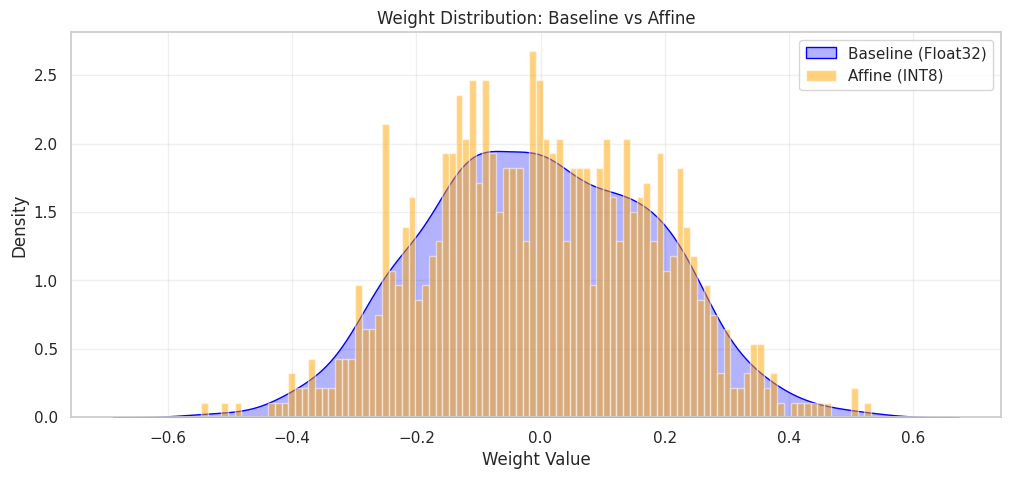

In [23]:
def plot_weight_histograms(baseline, quantized, quant_name):
    """
    Plots the continuous distribution of Baseline weights vs. 
    the discrete distribution of Quantized weights.
    """
    plt.figure(figsize=(12, 5))
    
    # 1. Baseline Weights (Float32)
    # Extract from first layer
    w_base = baseline.conv1.weight.detach().cpu().numpy().flatten()
    
    # 2. Quantized Weights (Int8 -> Dequantized to Float)
    # We unpack and then 'dequantize' to see what the approximate float values look like
    w_quant_packed = quantized.conv1._packed_params.unpack()[0]
    w_quant = w_quant_packed.dequantize().detach().cpu().numpy().flatten()
    
    # Plot
    sns.kdeplot(w_base, color='blue', fill=True, label='Baseline (Float32)', alpha=0.3)
    # Use a histogram for quantized to show the "bins" / discreteness
    plt.hist(w_quant, bins=100, color='orange', alpha=0.5, label=f'{quant_name} (INT8)', density=True)
    
    plt.title(f"Weight Distribution: Baseline vs {quant_name}")
    plt.xlabel("Weight Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run Visualization (Compare Baseline vs Affine)
print("\n--- Visualizing Quantization Effects ---")
model_base = load_model("Baseline", num_classes)
model_aff = load_model("Affine", num_classes)

if model_base and model_aff:
    plot_weight_histograms(model_base, model_aff, "Affine")